# Exploratory Data Analysis (EDA) - Kelompok 1

- `Kelp1_dataset_1.csv`: dataset mentah/kotor hasil scraping.
- `Kelp1_dataset_2.csv`: dataset hasil preprocessing.
- `db_nlp1_genap2526.jsonl`: data anotasi lengkap dari Prodigy.
- `nlp1_iaaa_textcat.jsonl`: hasil IRR klasifikasi teks/multi-label.
- `nlp1_iaaa.jsonl`: hasil IRR NER/span.

### Note
- Proses pengumpulan data dilakukan dengan cara scrapping google map reviews dengan software apify https://apify.com/compass/google-maps-reviews-scraper . Cakupan sumber data menggunakan google map dari sate kambing & ayam Pak Jogo dari Januari 2024 - saat ini

In [1]:
from pathlib import Path
import json
import re
from collections import Counter, defaultdict

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 120)

DATA_DIR = Path("../dataset")
RAW_PATH = DATA_DIR / "Kelp1_dataset_1.csv"
CLEAN_PATH = DATA_DIR / "Kelp1_dataset_2.csv"
ANNOTATION_PATH = DATA_DIR / "db_nlp1_genap2526.jsonl"
TEXTCAT_IRR_PATH = DATA_DIR / "nlp1_iaaa_textcat.jsonl"
NER_IRR_PATH = DATA_DIR / "nlp1_iaaa.jsonl"

Matplotlib is building the font cache; this may take a moment.


## 1. Fungsi bantu

In [2]:
LABELS = [
    "PRODUCT_POSITIVE", "PRODUCT_NEGATIVE", "PRODUCT_NEUTRAL",
    "PRICE_POSITIVE", "PRICE_NEGATIVE", "PRICE_NEUTRAL",
    "PLACE_POSITIVE", "PLACE_NEGATIVE", "PLACE_NEUTRAL",
    "PROMOTION_POSITIVE", "PROMOTION_NEGATIVE", "PROMOTION_NEUTRAL",
    "OUT_OF_TOPIC",
]

ASPEK_ID = {"PRODUCT": "Produk", "PRICE": "Harga", "PLACE": "Tempat", "PROMOTION": "Promosi", "OUT": "Di luar topik"}
SENTIMEN_ID = {"POSITIVE": "Positif", "NEGATIVE": "Negatif", "NEUTRAL": "Netral", "TOPIC": "Di luar topik"}

def norm_text(value):
    return re.sub(r"\s+", " ", str(value or "").strip())

def hitung_kata(text):
    return len(re.findall(r"\b\w+\b", str(text or "")))

def label_indonesia(label):
    label = str(label)
    if label == "OUT_OF_TOPIC":
        return "Di luar topik"
    parts = label.split("_")
    if len(parts) >= 2:
        return f"{ASPEK_ID.get(parts[0], parts[0].title())} - {SENTIMEN_ID.get(parts[1], parts[1].title())}"
    return label

def aspek_label(label):
    label = str(label)
    if label == "OUT_OF_TOPIC":
        return "Di luar topik"
    return ASPEK_ID.get(label.split("_")[0], label.split("_")[0].title())

def sentimen_label(label):
    label = str(label)
    if label == "OUT_OF_TOPIC":
        return "Di luar topik"
    parts = label.split("_")
    return SENTIMEN_ID.get(parts[1], parts[1].title()) if len(parts) > 1 else ""

def load_jsonl(path):
    rows = []
    with open(path, "r", encoding="utf-8-sig") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows

def load_json_or_jsonl(path):
    text = Path(path).read_text(encoding="utf-8-sig").strip()
    try:
        return json.loads(text)
    except json.JSONDecodeError:
        return load_jsonl(path)

## 2. Load dataset mentah, preprocessing, dan anotasi

In [3]:
raw_df = pd.read_csv(RAW_PATH)
clean_df = pd.read_csv(CLEAN_PATH)
annotation_rows = load_jsonl(ANNOTATION_PATH)

print("Jumlah baris dataset mentah:", len(raw_df))
print("Jumlah baris dataset preprocessing:", len(clean_df))
print("Jumlah baris anotasi:", len(annotation_rows))
print("Jumlah review unik pada anotasi:", len({norm_text(r.get("text", "")) for r in annotation_rows}))
print("Jumlah annotator:", len({r.get("_annotator_id") for r in annotation_rows if r.get("_annotator_id")}))

raw_df.head()

Jumlah baris dataset mentah: 3000
Jumlah baris dataset preprocessing: 915
Jumlah baris anotasi: 2745
Jumlah review unik pada anotasi: 915
Jumlah annotator: 3


,title,url,stars,name,reviewUrl,text
0,Sate Kambing & Ayam Pak Jogo,https://www.google.com/maps/search/?api=1&query=Sate%20Kambing%20%26%20Ayam%20Pak%20Jogo&query_place_id=ChIJrRhWGWhX...,5,Den Baguse,https://www.google.com/maps/reviews/data=!4m8!14m7!1m6!2m5!1sCi9DQUlRQUNvZENodHljRjlvT2poaVEwTlZVVzVSVW1SNE5XTk1UWEJ...,Mantapp pokoke
1,Sate Kambing & Ayam Pak Jogo,https://www.google.com/maps/search/?api=1&query=Sate%20Kambing%20%26%20Ayam%20Pak%20Jogo&query_place_id=ChIJrRhWGWhX...,4,danang adighani,https://www.google.com/maps/reviews/data=!4m8!14m7!1m6!2m5!1sCi9DQUlRQUNvZENodHljRjlvT2pVelpqbHVMVk5DTVZSRWRGVTFlRjl...,NaN
2,Sate Kambing & Ayam Pak Jogo,https://www.google.com/maps/search/?api=1&query=Sate%20Kambing%20%26%20Ayam%20Pak%20Jogo&query_place_id=ChIJrRhWGWhX...,5,Sony Oktavianus,https://www.google.com/maps/reviews/data=!4m8!14m7!1m6!2m5!1sCi9DQUlRQUNvZENodHljRjlvT2s5elNqZE9WREZOTm1rd1FuaFhRM0o...,"Kami kesini malam, jadi tidak panas, sejuk malan krn abis hujan.\nSate kambingnya enak, empuk. Gulai empuk dan enak ..."
3,Sate Kambing & Ayam Pak Jogo,https://www.google.com/maps/search/?api=1&query=Sate%20Kambing%20%26%20Ayam%20Pak%20Jogo&query_place_id=ChIJrRhWGWhX...,5,Trisca Fariana,https://www.google.com/maps/reviews/data=!4m8!14m7!1m6!2m5!1sCi9DQUlRQUNvZENodHljRjlvT201VFRVeE5iV1ZzTlZsSFNWUjBNbU5...,"Semua menu enak.\nPelayanan baik, ramah dan cepat.\nTempat bersih dan asri."
4,Sate Kambing & Ayam Pak Jogo,https://www.google.com/maps/search/?api=1&query=Sate%20Kambing%20%26%20Ayam%20Pak%20Jogo&query_place_id=ChIJrRhWGWhX...,4,Priyadi Septiono,https://www.google.com/maps/reviews/data=!4m8!14m7!1m6!2m5!1sCi9DQUlRQUNvZENodHljRjlvT25Cdk5HVjNTWGwwY0ZONk5XaDNaR3R...,NaN


## 3. Ringkasan preprocessing sederhana

Dataset `Kelp1_dataset_1.csv` masih berisi data kotor dari scraping Google Places, termasuk teks kosong, duplikasi, metadata nama reviewer, URL, dan rating. Dataset `Kelp1_dataset_2.csv` sudah berisi data yang dipakai untuk anotasi setelah cleaning sederhana, terutama kolom `title` dan `text`.

In [4]:
preprocessing_summary = pd.DataFrame({
    "Tahap": ["Dataset mentah", "Dataset preprocessing"],
    "Jumlah baris": [len(raw_df), len(clean_df)],
    "Jumlah teks tidak kosong": [raw_df["text"].notna().sum() if "text" in raw_df.columns else 0, clean_df["text"].notna().sum() if "text" in clean_df.columns else 0],
    "Jumlah teks unik": [raw_df["text"].map(norm_text).nunique() if "text" in raw_df.columns else 0, clean_df["text"].map(norm_text).nunique() if "text" in clean_df.columns else 0],
})
preprocessing_summary

,Tahap,Jumlah baris,Jumlah teks tidak kosong,Jumlah teks unik
0,Dataset mentah,3000,1656,1557
1,Dataset preprocessing,915,915,915


## 4. Agregasi anotasi

Setiap review dianotasi oleh beberapa annotator. Untuk kebutuhan EDA dan Streamlit, anotasi digabung menjadi satu label final per review menggunakan voting mayoritas. Pada data ini umumnya terdapat 3 annotator, sehingga sebuah label dianggap final jika dipilih oleh minimal 2 annotator. File anotasi asli tetap dipertahankan; agregasi hanya dipakai untuk analisis dan visualisasi.

In [5]:
raw_df["text_norm"] = raw_df.get("text", pd.Series(dtype=str)).map(norm_text)
clean_df["text_norm"] = clean_df["text"].map(norm_text)

raw_meta = (raw_df.dropna(subset=["text"])
            .drop_duplicates("text_norm")
            .set_index("text_norm")[["title", "stars"]]
            .to_dict("index"))
clean_meta = (clean_df.drop_duplicates("text_norm")
              .set_index("text_norm")[["title"]]
              .to_dict("index"))

by_text = defaultdict(list)
for row in annotation_rows:
    by_text[norm_text(row.get("text", ""))].append(row)

review_rows = []
label_rows = []
entity_rows = []

for review_id, (text_norm, rows) in enumerate(by_text.items(), start=1):
    text = rows[0].get("text", text_norm)
    annotators = sorted({r.get("_annotator_id", "") for r in rows if r.get("_annotator_id")})
    n_annotators = len(annotators) if annotators else len(rows)
    min_votes = 1 if n_annotators <= 1 else (n_annotators // 2 + 1)

    label_counts = Counter()
    for r in rows:
        for lab in r.get("accept") or []:
            label_counts[lab] += 1

    final_labels = [lab for lab in LABELS if label_counts.get(lab, 0) >= min_votes]
    if not final_labels and label_counts:
        max_vote = max(label_counts.values())
        final_labels = [lab for lab in LABELS if label_counts.get(lab, 0) == max_vote]

    meta = dict(clean_meta.get(text_norm, {}))
    meta.update(raw_meta.get(text_norm, {}))

    review_rows.append({
        "review_id": review_id,
        "category": "Kuliner",
        "business_name": meta.get("title", ""),
        "rating": meta.get("stars", ""),
        "review_text": text,
        "word_count": hitung_kata(text),
        "token_count": len(rows[0].get("tokens") or []),
        "n_annotations": len(rows),
        "n_annotators": n_annotators,
        "final_labels": final_labels,
        "final_labels_id": ", ".join(label_indonesia(l) for l in final_labels),
    })

    for lab in final_labels:
        label_rows.append({
            "review_id": review_id,
            "kode_label": lab,
            "label": label_indonesia(lab),
            "aspek": aspek_label(lab),
            "sentimen": sentimen_label(lab),
            "jumlah_annotator_setuju": label_counts.get(lab, 0),
            "jumlah_annotator": n_annotators,
        })

    for r in rows:
        for sp in r.get("spans") or []:
            start, end = sp.get("start"), sp.get("end")
            entitas = text[start:end] if isinstance(start, int) and isinstance(end, int) else sp.get("text", "")
            lab = sp.get("label", "")
            entity_rows.append({
                "review_id": review_id,
                "annotator_id": r.get("_annotator_id", ""),
                "entitas": norm_text(entitas),
                "kode_label": lab,
                "label": label_indonesia(lab),
                "aspek": aspek_label(lab),
                "sentimen": sentimen_label(lab),
            })

reviews_df = pd.DataFrame(review_rows)
labels_df = pd.DataFrame(label_rows)
entities_df = pd.DataFrame(entity_rows)

print("Jumlah review hasil agregasi:", len(reviews_df))
print("Jumlah label ABSA final:", len(labels_df))
print("Jumlah entitas NER/span:", len(entities_df))

reviews_df.head()

Jumlah review hasil agregasi: 915
Jumlah label ABSA final: 1750
Jumlah entitas NER/span: 7106


,review_id,category,business_name,rating,review_text,word_count,token_count,n_annotations,n_annotators,final_labels,final_labels_id
0,1,Kuliner,Sate Kambing & Ayam Pak Jogo,5,"Kami kesini malam, jadi tidak panas, sejuk malan krn abis hujan. Sate kambingnya enak, empuk. Gulai empuk dan enak j...",28,37,3,3,"[PRODUCT_POSITIVE, PLACE_POSITIVE, PROMOTION_POSITIVE]","Produk - Positif, Tempat - Positif, Promosi - Positif"
1,2,Kuliner,Sate Kambing & Ayam Pak Jogo,5,"Semua menu enak. Pelayanan baik, ramah dan cepat. Tempat bersih dan asri.",12,16,3,3,"[PRODUCT_POSITIVE, PLACE_POSITIVE]","Produk - Positif, Tempat - Positif"
2,3,Kuliner,Sate Kambing & Ayam Pak Jogo,5,"Muantaaaaap poooool RM yang setia dikunjungi tiap gelaran kustomfest, atau acara acara apapun di JEC tiap ke jogja n...",30,34,3,3,"[PRODUCT_POSITIVE, PROMOTION_POSITIVE]","Produk - Positif, Promosi - Positif"
3,4,Kuliner,Sate Kambing & Ayam Pak Jogo,5,Makanannya saya rekomendasi karena enak dan lezat. Lokasi ada di map.,11,13,3,3,[PRODUCT_POSITIVE],Produk - Positif
4,5,Kuliner,Sate Kambing & Ayam Pak Jogo,5,my father favourite satay and tengkleng house in Jogjakarta. the important thing it has big parking area,17,18,3,3,"[PLACE_POSITIVE, PROMOTION_POSITIVE]","Tempat - Positif, Promosi - Positif"


## 5. Distribusi label ABSA

In [6]:
label_dist = labels_df["label"].value_counts().reset_index()
label_dist.columns = ["Label", "Jumlah"]
label_dist

,Label,Jumlah
0,Produk - Positif,709
1,Tempat - Positif,382
2,Produk - Negatif,128
3,Produk - Netral,127
4,Harga - Positif,114
5,Tempat - Negatif,83
6,Harga - Netral,53
7,Tempat - Netral,50
8,Di luar topik,48
9,Promosi - Positif,34


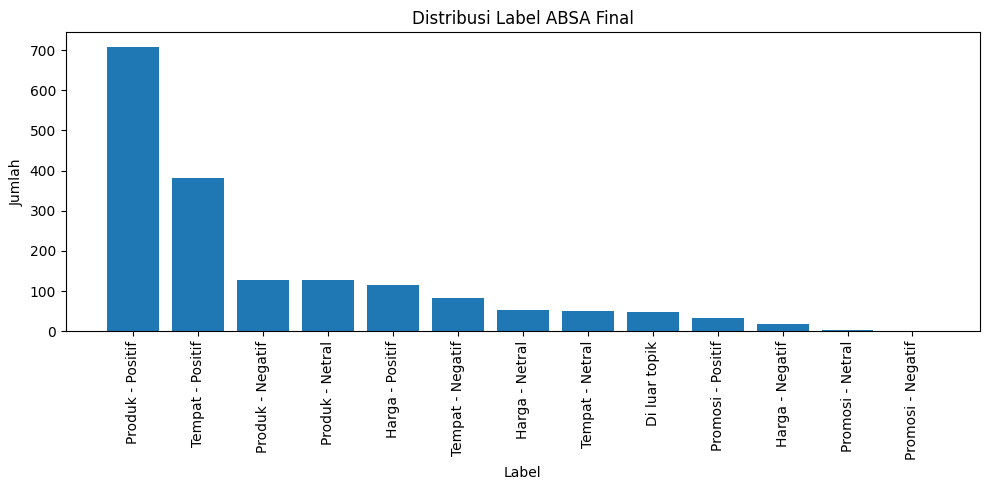

In [7]:
plt.figure(figsize=(10, 5))
plt.bar(label_dist["Label"], label_dist["Jumlah"])
plt.xticks(rotation=90)
plt.xlabel("Label")
plt.ylabel("Jumlah")
plt.title("Distribusi Label ABSA Final")
plt.tight_layout()
plt.show()

## 6. Distribusi aspek dan sentimen

In [8]:
aspect_dist = labels_df["aspek"].value_counts().reset_index()
aspect_dist.columns = ["Aspek", "Jumlah"]
aspect_dist

,Aspek,Jumlah
0,Produk,964
1,Tempat,515
2,Harga,184
3,Di luar topik,48
4,Promosi,39


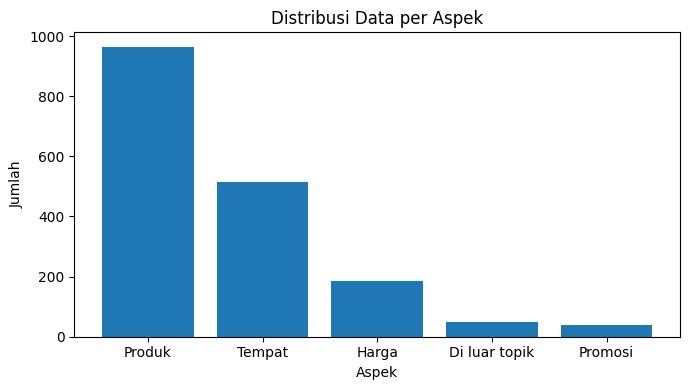

,Sentimen,Jumlah
0,Positif,1239
1,Netral,234
2,Negatif,229
3,Di luar topik,48


In [9]:
plt.figure(figsize=(7, 4))
plt.bar(aspect_dist["Aspek"], aspect_dist["Jumlah"])
plt.xlabel("Aspek")
plt.ylabel("Jumlah")
plt.title("Distribusi Data per Aspek")
plt.tight_layout()
plt.show()

sentiment_dist = labels_df["sentimen"].value_counts().reset_index()
sentiment_dist.columns = ["Sentimen", "Jumlah"]
sentiment_dist

## 7. Distribusi entitas NER / span ABSA

In [10]:
entity_label_dist = entities_df["label"].value_counts().reset_index()
entity_label_dist.columns = ["Label Entitas", "Jumlah"]
entity_label_dist.head(20)

,Label Entitas,Jumlah
0,Produk - Positif,2947
1,Tempat - Positif,1537
2,Produk - Netral,658
3,Produk - Negatif,457
4,Harga - Positif,339
5,Tempat - Negatif,294
6,Tempat - Netral,216
7,Promosi - Positif,207
8,Di luar topik,205
9,Harga - Netral,175


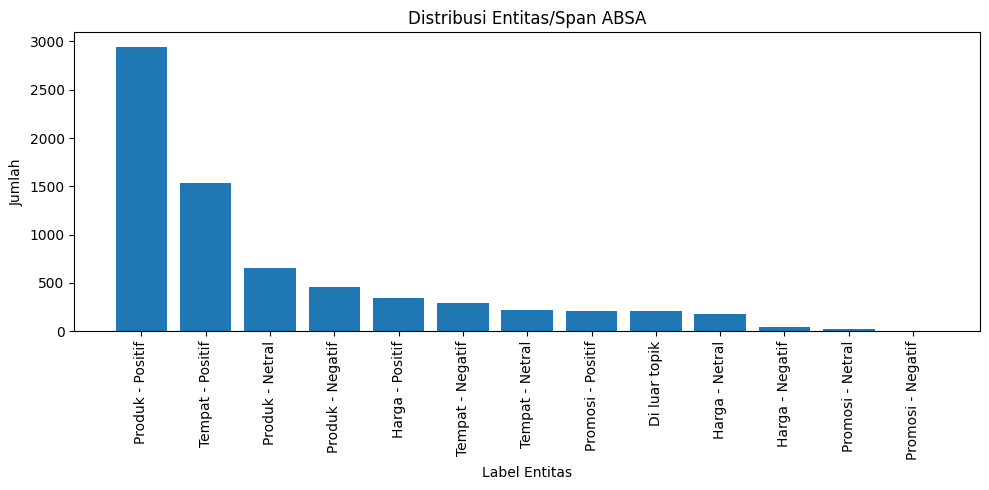

In [11]:
plt.figure(figsize=(10, 5))
plt.bar(entity_label_dist["Label Entitas"], entity_label_dist["Jumlah"])
plt.xticks(rotation=90)
plt.xlabel("Label Entitas")
plt.ylabel("Jumlah")
plt.title("Distribusi Entitas/Span ABSA")
plt.tight_layout()
plt.show()

## 8. Distribusi panjang review

In [12]:
reviews_df[["word_count", "token_count"]].describe()

,word_count,token_count
count,915.000000,915.000000
mean,21.363934,25.377049
std,24.028835,28.335458
min,6.000000,5.000000
25%,8.000000,10.000000
50%,14.000000,16.000000
75%,24.000000,29.000000
max,286.000000,327.000000


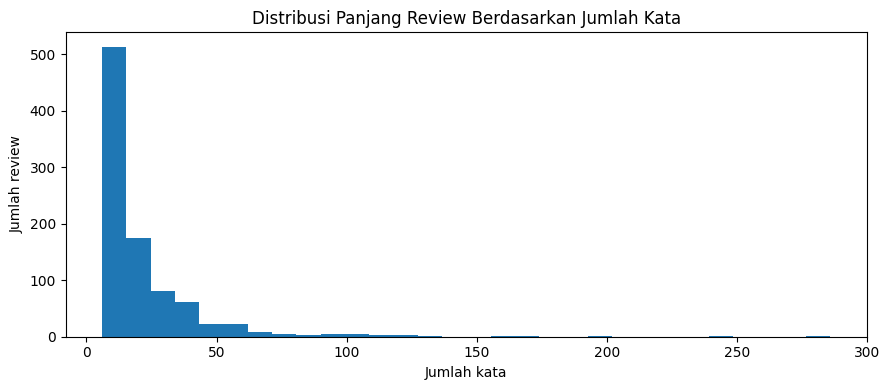

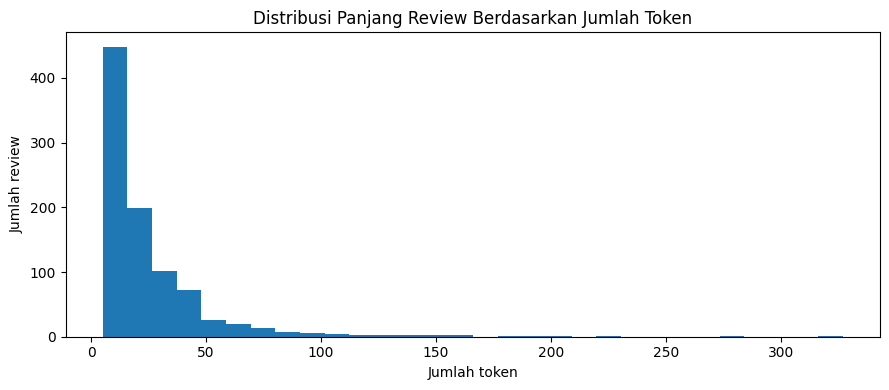

In [13]:
plt.figure(figsize=(9, 4))
plt.hist(reviews_df["word_count"], bins=30)
plt.xlabel("Jumlah kata")
plt.ylabel("Jumlah review")
plt.title("Distribusi Panjang Review Berdasarkan Jumlah Kata")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 4))
plt.hist(reviews_df["token_count"], bins=30)
plt.xlabel("Jumlah token")
plt.ylabel("Jumlah review")
plt.title("Distribusi Panjang Review Berdasarkan Jumlah Token")
plt.tight_layout()
plt.show()

## 9. Matriks korelasi antar label

In [14]:
label_matrix = pd.crosstab(labels_df["review_id"], labels_df["kode_label"])
label_matrix = label_matrix.reindex(columns=[l for l in LABELS if l in label_matrix.columns], fill_value=0)
label_corr = label_matrix.corr()
label_corr_display = label_corr.copy()
label_corr_display.index = [label_indonesia(i) for i in label_corr_display.index]
label_corr_display.columns = [label_indonesia(c) for c in label_corr_display.columns]
label_corr_display

,Produk - Positif,Produk - Negatif,Produk - Netral,Harga - Positif,Harga - Negatif,Harga - Netral,Tempat - Positif,Tempat - Negatif,Tempat - Netral,Promosi - Positif,Promosi - Negatif,Promosi - Netral,Di luar topik
Produk - Positif,1.000000,-0.216723,-0.152275,0.107413,-0.060046,0.085039,0.032051,-0.145192,-0.160101,-0.131364,-0.070668,-0.141579,-0.232515
Produk - Negatif,-0.216723,1.000000,0.159456,-0.122406,0.035264,0.016549,-0.111510,0.031100,0.009207,-0.033327,0.081691,-0.028157,-0.100110
Produk - Netral,-0.152275,0.159456,1.000000,-0.025105,0.012323,0.044643,-0.004163,-0.012056,0.093940,0.000809,0.082067,0.068194,-0.028378
Harga - Positif,0.107413,-0.122406,-0.025105,1.000000,-0.054684,-0.041702,0.103256,-0.079415,-0.066382,-0.025393,-0.013140,0.024017,-0.033937
Harga - Negatif,-0.060046,0.035264,0.012323,-0.054684,1.000000,-0.001155,-0.091066,0.039057,0.072254,0.014447,-0.004778,-0.009572,-0.034033
Harga - Netral,0.085039,0.016549,0.044643,-0.041702,-0.001155,1.000000,0.084958,0.064690,0.040485,-0.026445,-0.008620,-0.017269,0.001738
Tempat - Positif,0.032051,-0.111510,-0.004163,0.103256,-0.091066,0.084958,1.000000,-0.010712,0.080492,0.060963,-0.029917,-0.025733,-0.040817
Tempat - Negatif,-0.145192,0.031100,-0.012056,-0.079415,0.039057,0.064690,-0.010712,1.000000,0.104896,-0.024956,-0.010990,-0.022018,-0.044014
Tempat - Netral,-0.160101,0.009207,0.093940,-0.066382,0.072254,0.040485,0.080492,0.104896,1.000000,0.026768,-0.008357,-0.016742,0.113496
Promosi - Positif,-0.131364,-0.033327,0.000809,-0.025393,0.014447,-0.026445,0.060963,-0.024956,0.026768,1.000000,-0.006825,0.161672,0.211144


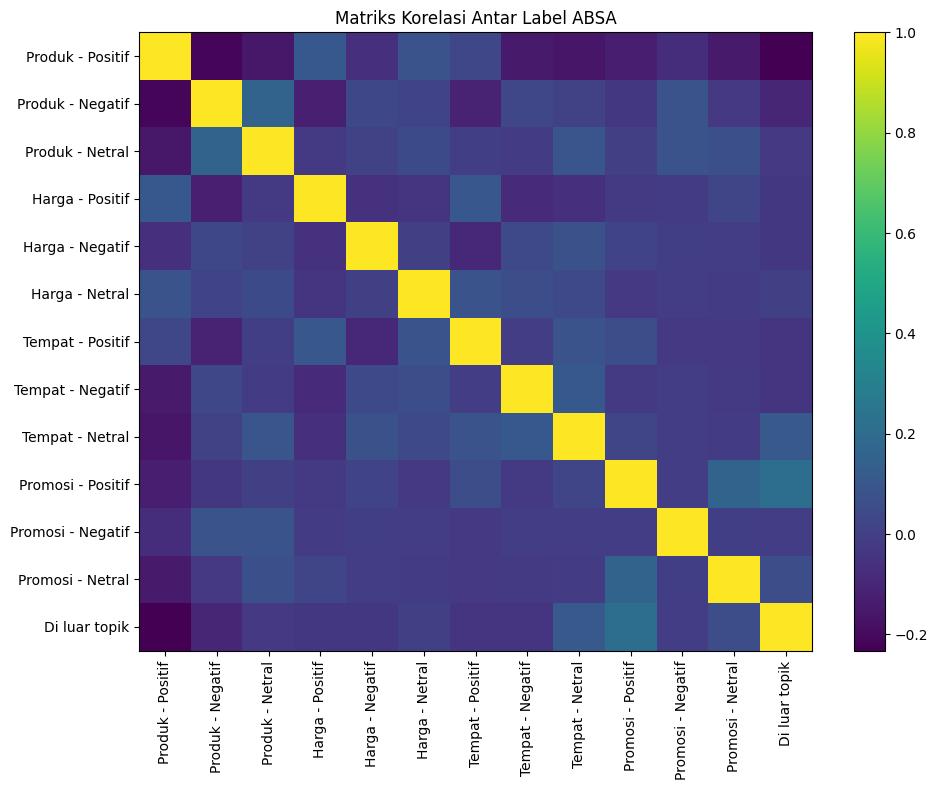

In [15]:
plt.figure(figsize=(10, 8))
plt.imshow(label_corr.values, aspect="auto")
plt.xticks(range(len(label_corr.columns)), [label_indonesia(c) for c in label_corr.columns], rotation=90)
plt.yticks(range(len(label_corr.index)), [label_indonesia(i) for i in label_corr.index])
plt.colorbar()
plt.title("Matriks Korelasi Antar Label ABSA")
plt.tight_layout()
plt.show()

## 10. Inter-Annotator Agreement (IRR)

In [16]:
textcat_irr = load_json_or_jsonl(TEXTCAT_IRR_PATH)
ner_irr = load_json_or_jsonl(NER_IRR_PATH)

textcat_irr_df = pd.DataFrame([
    {"kode_label": label, "label": label_indonesia(label), **metrics}
    for label, metrics in textcat_irr.items()
])
textcat_irr_df.head(13)

,kode_label,label,n_examples,n_categories,n_coincident_examples,n_single_annotation,n_annotators,avg_raters_per_example,percent_agreement,kripp_alpha,gwet_ac2
0,PRODUCT_POSITIVE,Produk - Positif,2544,13,902,13,3,2.780328,0.820769,0.604483,0.718445
1,PRODUCT_NEGATIVE,Produk - Negatif,2544,13,902,13,3,2.780328,0.878049,0.687058,0.834315
2,PRODUCT_NEUTRAL,Produk - Netral,2544,13,902,13,3,2.780328,0.748707,0.295100,0.632083
3,PRICE_POSITIVE,Harga - Positif,2544,13,902,13,3,2.780328,0.876940,0.681305,0.833998
4,PRICE_NEGATIVE,Harga - Negatif,2544,13,902,13,3,2.780328,0.934959,0.640620,0.928969
5,PRICE_NEUTRAL,Harga - Netral,2544,13,902,13,3,2.780328,0.888027,0.456299,0.867772
6,PLACE_POSITIVE,Tempat - Positif,2544,13,902,13,3,2.780328,0.813378,0.711107,0.636511
7,PLACE_NEGATIVE,Tempat - Negatif,2544,13,902,13,3,2.780328,0.911308,0.759018,0.889027
8,PLACE_NEUTRAL,Tempat - Netral,2544,13,902,13,3,2.780328,0.849593,0.248683,0.817897
9,PROMOTION_POSITIVE,Promosi - Positif,2544,13,902,13,3,2.780328,0.777162,-0.035301,0.718719


In [17]:
ner_summary = pd.DataFrame([
    {"metrik": key, "nilai": value}
    for key, value in ner_irr.items()
    if not isinstance(value, (list, dict))
])
ner_summary

,metrik,nilai
0,n_examples,2745.00
1,n_categories,13.00
2,n_coincident_examples,915.00
3,n_single_annotation,0.00
4,n_annotators,3.00
5,avg_raters_per_example,3.00
6,pairwise_f1,0.21
7,pairwise_recall,0.21
8,pairwise_precision,0.23
